In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pandas as pd
import glob
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, accuracy_score
)
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import itertools

import ast  # para convertir el string con los keypoints a lista Python

In [7]:
# -------------------------------------------------------
# CARGA DE DATOS
# -------------------------------------------------------
sequence_length = 30
all_sequences, all_labels = [], []

csv_files = glob.glob("Data/merged_keypoints/*.csv")

for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    # Filtrar frames con keypoints válidos
    df = df[df["has_keypoints"] == True].reset_index(drop=True)
    if len(df) < sequence_length:
        continue

    # Convertir los strings JSON de keypoints a listas de tuplas
    df["keypoints"] = df["keypoints"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

    # Aplanar los keypoints [(x1, y1), (x2, y2)...] -> [x1, y1, x2, y2, ...]
    df["flat_keypoints"] = df["keypoints"].apply(lambda pts: np.array(pts).flatten() if pts else np.zeros(66))

    # Convertir a matriz numpy (frames × features)
    features = np.stack(df["flat_keypoints"].to_numpy())
    labels = df["etiqueta"].to_numpy()

    # Crear secuencias deslizantes
    for start_idx in range(len(df) - sequence_length + 1):
        end_idx = start_idx + sequence_length
        seq = features[start_idx:end_idx]
        label = labels[end_idx - 1]
        all_sequences.append(seq)
        all_labels.append(label)

# -------------------------------------------------------
# CONVERTIR A TENSORES
# -------------------------------------------------------
X = np.array(all_sequences)
y = np.array(all_labels)

print("Shape de X:", X.shape)  # (num_sequences, 30, 66)
print("Shape de y:", y.shape)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y + 1, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
print("✅ Dataset creado correctamente con keypoints en formato JSON")

print("Valores únicos de etiquetas:", torch.unique(y_tensor))

Shape de X: (23424, 30, 66)
Shape de y: (23424,)
✅ Dataset creado correctamente con keypoints en formato JSON
Valores únicos de etiquetas: tensor([0, 1, 2])


In [8]:
# -------------------------------------------------------
# DIVISIÓN TRAIN / VALID / TEST
# -------------------------------------------------------
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [9]:
# -------------------------------------------------------
# MODELO LSTM
# -------------------------------------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=66, hidden_size=128, num_layers=2, num_classes=3):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]  # último paso temporal
        out = self.fc(out)
        return out

Epoch [1/20] | Train Loss: 0.2174 | Val Loss: 0.1520 | Val Acc: 0.9527
Epoch [2/20] | Train Loss: 0.1224 | Val Loss: 0.1109 | Val Acc: 0.9644
Epoch [3/20] | Train Loss: 0.1068 | Val Loss: 0.0960 | Val Acc: 0.9684
Epoch [4/20] | Train Loss: 0.0896 | Val Loss: 0.0830 | Val Acc: 0.9750
Epoch [5/20] | Train Loss: 0.0726 | Val Loss: 0.0711 | Val Acc: 0.9750
Epoch [6/20] | Train Loss: 0.0681 | Val Loss: 0.0762 | Val Acc: 0.9738
Epoch [7/20] | Train Loss: 0.0612 | Val Loss: 0.0626 | Val Acc: 0.9769
Epoch [8/20] | Train Loss: 0.0510 | Val Loss: 0.0825 | Val Acc: 0.9732
Epoch [9/20] | Train Loss: 0.0492 | Val Loss: 0.0608 | Val Acc: 0.9781
Epoch [10/20] | Train Loss: 0.0439 | Val Loss: 0.0481 | Val Acc: 0.9826
Epoch [11/20] | Train Loss: 0.0427 | Val Loss: 0.0441 | Val Acc: 0.9855
Epoch [12/20] | Train Loss: 0.0373 | Val Loss: 0.0475 | Val Acc: 0.9835
Epoch [13/20] | Train Loss: 0.0500 | Val Loss: 0.0502 | Val Acc: 0.9838
Epoch [14/20] | Train Loss: 0.0346 | Val Loss: 0.0427 | Val Acc: 0.9843
E

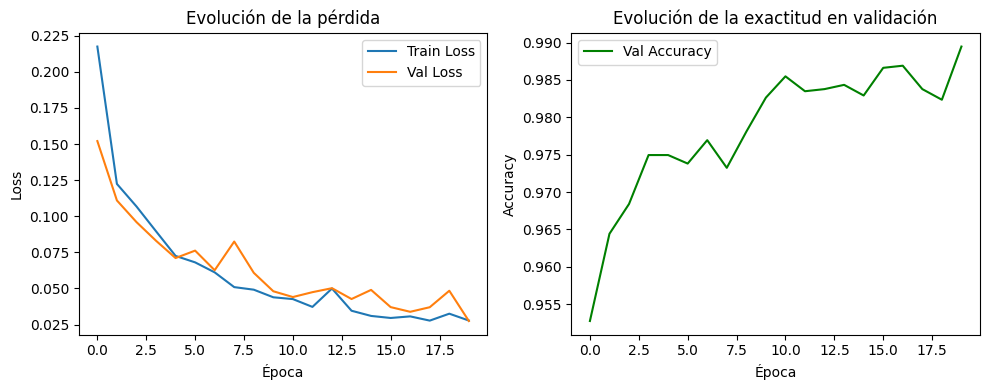


=== REPORTE DE CLASIFICACIÓN (TEST) ===
              precision    recall  f1-score   support

           0     0.9974    0.9956    0.9965      2717
           1     0.9267    0.8894    0.9077       199
           2     0.9755    0.9967    0.9860       599

    accuracy                         0.9898      3515
   macro avg     0.9665    0.9606    0.9634      3515
weighted avg     0.9897    0.9898    0.9897      3515



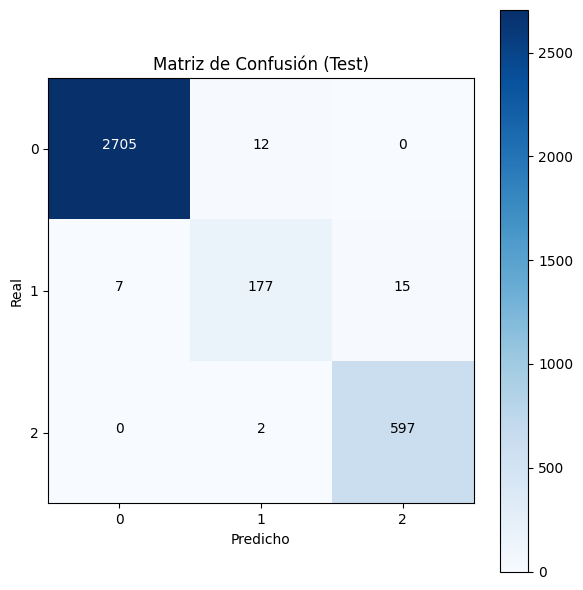

In [10]:

# -------------------------------------------------------
# ENTRENAMIENTO CON VALIDACIÓN
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(input_size=66, hidden_size=128, num_layers=2, num_classes=len(np.unique(y))).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses, val_losses, val_accuracies = [], [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # ---- Entrenamiento ----
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validación ----
    model.eval()
    val_loss = 0
    y_val_true, y_val_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            y_val_true.extend(y_batch.cpu().numpy())
            y_val_pred.extend(preds.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    # Guardar el mejor modelo
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_lstm_model.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

# -------------------------------------------------------
# GRÁFICAS DE PÉRDIDA Y PRECISIÓN
# -------------------------------------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de la pérdida")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución de la exactitud en validación")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# EVALUACIÓN FINAL EN TEST
# -------------------------------------------------------
model.load_state_dict(torch.load("best_lstm_model.pth"))
model.eval()

y_true, y_pred, y_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)

print("\n=== REPORTE DE CLASIFICACIÓN (TEST) ===")
print(classification_report(y_true, y_pred, digits=4))

# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Matriz de Confusión (Test)")
plt.colorbar()
classes = [str(i) for i in range(len(np.unique(y)))]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicho")
plt.ylabel("Real")

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], "d"), horizontalalignment="center",
             color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()